# XGB 预测个股收益、评估因子重要性（A 股面板）

In [90]:
import pandas as pd
import numpy as np

In [91]:
c=pd.read_parquet('D:/学习资料/数据/2016-2026数据.parquet')

In [92]:
#获取基础信息数据，获取基础信息数据，包括股票代码、名称、上市日期、退市日期等
#包括股票代码、上市状态、行业、上市日期等
#当前所有上市、退市的股票列表
stock_basic = pd.read_csv("D:/学习资料/数据/stock_basic3.csv")
stock_basic['list_date']=pd.to_datetime(stock_basic['list_date'])
# 预提取上市日期映射，后续直接匹配，减少merge开销
list_date_map = dict(zip(stock_basic["ts_code"], stock_basic["list_date"]))


In [93]:
#合并上市日期数据
c["list_date"] = c["ts_code"].map(list_date_map)

In [94]:
#查看缺失值
c.isna().sum()

ts_code                 0
trade_date              0
turnover_rate           0
volume_ratio        15975
pe                1473641
pe_ttm            1855797
pb                  64837
ps                   3351
ps_ttm               8069
float_share             0
total_mv                0
circ_mv                 0
limit_status      7665217
suspend_type     10315695
type             10029098
open                    0
high                    0
low                     0
close                   0
change                  0
pct_chg                 0
vol                     0
amount                  0
adj_factor              0
l1_code              3723
l1_name              3723
out_date         10315695
list_date            3723
dtype: int64

In [95]:
len(c)

10315695

In [96]:
c[c['suspend_type']=='S' ][['ts_code','trade_date','open','suspend_type','type']].head()

,ts_code,trade_date,open,suspend_type,type


In [97]:
c[['pct_chg','limit_status']].head()

,pct_chg,limit_status
0,-8.27,NaN
1,-10.00,NaN
2,-10.02,NaN
3,-3.58,NaN
4,-9.97,NaN


# 处理缺失值

# 看数据结构

In [98]:
c.columns

Index(['ts_code', 'trade_date', 'turnover_rate', 'volume_ratio', 'pe',
       'pe_ttm', 'pb', 'ps', 'ps_ttm', 'float_share', 'total_mv', 'circ_mv',
       'limit_status', 'suspend_type', 'type', 'open', 'high', 'low', 'close',
       'change', 'pct_chg', 'vol', 'amount', 'adj_factor', 'l1_code',
       'l1_name', 'out_date', 'list_date'],
      dtype='str')

In [99]:
df=c[['ts_code', 'trade_date', 'turnover_rate', 'volume_ratio', 'pe',
       'pe_ttm', 'pb', 'ps', 'ps_ttm', 'float_share', 'total_mv', 'circ_mv',
       'limit_status', 'suspend_type', 'type', 'open', 'high', 'low', 'close',
       'change', 'pct_chg', 'vol', 'amount', 'adj_factor', 'l1_code',
       'l1_name', 'out_date', 'list_date']]

In [100]:
df=df.rename(columns={'l1_name':'hangye','type':'st_type'})

In [101]:
df.columns

Index(['ts_code', 'trade_date', 'turnover_rate', 'volume_ratio', 'pe',
       'pe_ttm', 'pb', 'ps', 'ps_ttm', 'float_share', 'total_mv', 'circ_mv',
       'limit_status', 'suspend_type', 'st_type', 'open', 'high', 'low',
       'close', 'change', 'pct_chg', 'vol', 'amount', 'adj_factor', 'l1_code',
       'hangye', 'out_date', 'list_date'],
      dtype='str')

# 开始处理

In [102]:
df['trade_date'] = pd.to_datetime(df['trade_date'])  # 日期
df['list_date'] = pd.to_datetime(df['list_date'])  # 日期

In [103]:
# 依据 股票代码+交易日 整体去重，保留第一条重复数据
df = df.drop_duplicates(subset=["ts_code", "trade_date"], keep="first")

In [104]:
len(df)

10135300

In [105]:
df.isna().sum()

ts_code                 0
trade_date              0
turnover_rate           0
volume_ratio        15794
pe                1451865
pe_ttm            1828445
pb                  63798
ps                   3315
ps_ttm               7892
float_share             0
total_mv                0
circ_mv                 0
limit_status      7527522
suspend_type     10135300
st_type           9853540
open                    0
high                    0
low                     0
close                   0
change                  0
pct_chg                 0
vol                     0
amount                  0
adj_factor              0
l1_code              3653
hangye               3653
out_date         10135300
list_date            3653
dtype: int64

In [106]:
#设置多重索引
df=df.set_index(['ts_code', 'trade_date'])

In [107]:
# 确保按股票代码分组后，按时间排序
df = df.sort_index(level=["ts_code", "trade_date"], ascending=[True, True])

In [108]:
df["suspend_type"].nunique()

0

In [109]:
#得到后复权的价格
df['open']=df['open']*df['adj_factor']
df['high']=df['high']*df['adj_factor']
df['low']=df['low']*df['adj_factor']
df['close']=df['close']*df['adj_factor']

In [110]:
#个股内向前填充收盘价（维持时序连续）
df["close_fill"] = df.groupby(level="ts_code")["close"].ffill()######pandas 针对 pct_change / shift / diff / ffill / bfill 这类逐行时序运算，分组执行后自动保留原始完整多层索引、行数完全不变，
df["pe_fill"] = df.groupby(level="ts_code")["pe"].ffill()######
df["pe_ttm_fill"] = df.groupby(level="ts_code")["pe_ttm"].ffill()######
df["ps_fill"] = df.groupby(level="ts_code")["ps"].ffill()
df["ps_ttm_fill"] = df.groupby(level="ts_code")["ps_ttm"].ffill()
df["pb_fill"] = df.groupby(level="ts_code")["pb"].ffill()

In [111]:
# 4. 定义目标变量：未来N日收益率（这里以未来5日收益率为例）
df['target_return_5d'] = df.groupby(level='ts_code')['close_fill'].shift(-5) / df['close_fill'] - 1

In [112]:
#==========================保留个股首次被标记为ST之前的全部数据，剔除ST当日及后续所有风险数据，规避风险股异常波动干扰；================
##获取每只股票首次ST日期
df["first_st_date"]  = df[df["st_type"].notna()]['st_type'].groupby(level="ts_code").transform(lambda x: x.index.get_level_values("trade_date").min())
 

####筛选：保留首次ST之前的数据；没有出现过ST的全部保留
# 条件解释：如果first_st_date为空（从未ST）条件自动为True
# 下面同样用索引日期做筛选
date_arr = df.index.get_level_values("trade_date")
mask = (date_arr < df["first_st_date"]) | df["first_st_date"].isna()###布尔掩码
df = df[mask].copy()

In [113]:
df["suspend_type"] = df["suspend_type"].notna()#原地覆盖布尔

In [114]:
#构造筛选条件
#cond1 = df["suspend_type"].isin(['S'])       # 删除停牌
#########cond2 = ~(abs(daily_basic["pct_chg"])>=10)        # 预测不删除删除涨跌停+-10%

#df = df[cond1]

# === 标记复牌首日（昨天停牌，今天有量）===
df['prev_suspended'] = df.groupby(level='ts_code')['suspend_type'].shift(1).fillna(False)

In [115]:
def mask_cross_suspension_returns(df, forward_period=5):
    """
    二次标记：检查 T 日的 forward_return 是否跨越了停牌/复牌

    检查 T+1 到 T+{forward_period} 这 N 天中每一天：
    - 如果是停牌日     → T 日的标签作废（持有期不足 N 天）
    - 如果是复牌首日   → T 日的标签作废（含有复牌跳空，非正常收益）

    Parameters:
    - df: 含 'is_suspended' 和 'prev_suspended' 列的完整数据
    - forward_period: 前向窗口，如 5 表示 T+5

    Returns:
    - df: forward_return 列中被污染的置为 NaN
    """

    for offset in range(1, forward_period + 1):
        # 未来第 offset 天是否停牌
        future_suspended = df.groupby(level='ts_code')['suspend_type'].shift(-offset)

        # 未来第 offset 天是否是复牌首日
        future_resumed = df.groupby(level='ts_code')['prev_suspended'].shift(-offset)

        # 任一命中 → 该 T 日的标签污染
        bad = future_suspended.eq(True) | future_resumed.eq(True)

        df.loc[bad, 'target_return_5d'] = np.nan

    return df

In [116]:
print("=" * 70)
print("二次标记之前:")
print("=" * 70)
print(df[[ 'close', 'suspend_type', 'prev_suspended', 'target_return_5d']])
print(len(df))

二次标记之前:
                           close  suspend_type prev_suspended  \
ts_code   trade_date                                            
000001.SZ 2016-01-04  974.312020         False          False   
          2016-01-05  980.331600         False          False   
          2016-01-06  991.510820         False          False   
          2016-01-07  940.774360         False          False   
          2016-01-08  956.253280         False          False   
...                          ...           ...            ...   
920992.BJ 2025-12-25   26.922396         False          False   
          2025-12-26   26.340048         False          False   
          2025-12-29   25.921952         False          False   
          2025-12-30   25.951816         False          False   
          2025-12-31   25.966748         False          False   

                      target_return_5d  
ts_code   trade_date                    
000001.SZ 2016-01-04         -0.050309  
          2016-01-05   

In [117]:
# ===  二次标记 ===
df = df.groupby(level="ts_code").apply(
    lambda sub_df: mask_cross_suspension_returns(sub_df, forward_period=5)
).droplevel(0)


In [118]:
print("=" * 70)
print("二次标记之后:")
print("=" * 70)
print(df[[ 'close', 'suspend_type', 'prev_suspended', 'target_return_5d']])
print(len(df))

二次标记之后:
                           close  suspend_type prev_suspended  \
ts_code   trade_date                                            
000001.SZ 2016-01-04  974.312020         False          False   
          2016-01-05  980.331600         False          False   
          2016-01-06  991.510820         False          False   
          2016-01-07  940.774360         False          False   
          2016-01-08  956.253280         False          False   
...                          ...           ...            ...   
920992.BJ 2025-12-25   26.922396         False          False   
          2025-12-26   26.340048         False          False   
          2025-12-29   25.921952         False          False   
          2025-12-30   25.951816         False          False   
          2025-12-31   25.966748         False          False   

                      target_return_5d  
ts_code   trade_date                    
000001.SZ 2016-01-04         -0.050309  
          2016-01-05   

In [119]:
# 剔除上市日期全部为空的所有个股
all_null_mask = df.groupby(level="ts_code")["list_date"].transform(lambda x: x.isna().all())#" 先标记：每组(单只股票)list_date是否全部为空,都是 NaN 才删除；如果只是个别行空值，用下面方式填充同股票上市日期
df = df[~all_null_mask]
# 个股内部上市日期是固定不变值，个股内填充缺失的list_date
df["list_date"] = df.groupby(level="ts_code")["list_date"].transform("ffill").transform("bfill")
# 填充完依旧为空的股票彻底删掉
#df = df[df["list_date"].notna()].copy()

In [120]:
df['list_date'].isna().sum()

np.int64(0)

In [121]:
#df['is_limit_up_down']=df['pct_chg'].apply(lambda x :1 if abs(x)>10 else 0)

#向量化运算
df['is_limit_up_down'] = np.where(np.abs(df['pct_chg']) > 10, 1, 0)

In [122]:
df.head(2)

turnover_rate  volume_ratio      pe  pe_ttm      pb  \
ts_code   trade_date                                                        
000001.SZ 2016-01-04         0.4774          0.98  8.1869  7.4202  1.0317   
          2016-01-05         0.5619          1.09  8.2375  7.4661  1.0381   

                          ps  ps_ttm   float_share      total_mv  \
ts_code   trade_date                                               
000001.SZ 2016-01-04  2.2085  1.8031  1.180405e+06  1.621173e+07   
          2016-01-05  2.2221  1.8143  1.180405e+06  1.631189e+07   

                           circ_mv  ...  close_fill  pe_fill pe_ttm_fill  \
ts_code   trade_date                ...                                    
000001.SZ 2016-01-04  1.337399e+07  ...   974.31202   8.1869      7.4202   
          2016-01-05  1.345662e+07  ...   980.33160   8.2375      7.4661   

                      ps_fill  ps_ttm_fill  pb_fill  target_return_5d  \
ts_code   trade_date                                                    
000001.SZ 2016-01-04   2.2085       1.8031   1.0317         -0.050309   
          2016-01-05   2.2221       1.8143   1.0381         -0.051754   

                      first_st_date  prev_suspended  is_limit_up_down  
ts_code   trade_date                                                   
000001.SZ 2016-01-04            NaT           False                 0  
          2016-01-05            NaT           False                 0  

[2 rows x 36 columns]

In [123]:
#剔除上市90天内的股票数据
df=df[(df.index.get_level_values("trade_date")-df['list_date']).dt.days > 90]

In [124]:
# 剔除行业为空的所有个股
df = df.dropna(subset=["hangye"], how="all")#how="all"：该股票整条 list_date 都是 NaN 才删除；如果只是个别行空值，用下面方式填充同股票上市日期

# 个股内部上市日期是固定不变值，个股内填充缺失的list_date
df["hangye"] = df.groupby(level="ts_code")["hangye"].transform("ffill").transform("bfill")
# 填充完依旧为空的股票彻底删掉
df = df[df["hangye"].notna()].copy()

In [125]:
#个股内向前填充收盘价（维持时序连续）
df["close_fill"] = df.groupby(level="ts_code")["close"].ffill()######pandas 针对 pct_change / shift / diff / ffill / bfill 这类逐行时序运算，分组执行后自动保留原始完整多层索引、行数完全不变，
df["pe_fill"] = df.groupby(level="ts_code")["pe"].ffill()######
df["pe_ttm_fill"] = df.groupby(level="ts_code")["pe_ttm"].ffill()######
df["ps_fill"] = df.groupby(level="ts_code")["ps"].ffill()
df["ps_ttm_fill"] = df.groupby(level="ts_code")["ps_ttm"].ffill()
df["pb_fill"] = df.groupby(level="ts_code")["pb"].ffill()

In [126]:
#1 计算技术因子
def calculate_technical_factors(price_df):
    df = price_df.copy()
    
    # 计算过去收益率
    df['return_1d'] = df.groupby(level='ts_code')['close_fill'].pct_change()#############= (当前值 /n 期前的值) − 1
    df['return_5d'] = df.groupby(level='ts_code')['close_fill'].pct_change(5)
    df['return_20d'] = df.groupby(level='ts_code')['close_fill'].pct_change(20)#pct= (当前值−前一期值)/前一期值

    ##一、====计算动量/趋势类因子 Momentum
    #简单移动平均
    df["ma5"] = df.groupby(level="ts_code")["close_fill"].transform(lambda x: x.rolling(5).mean())
    df['ma20'] = df.groupby(level="ts_code")["close_fill"].rolling(20).mean().droplevel(0)
    
    #均线斜率（线性回归法）
    def rolling_linreg_slope(window_arr):
        # window_arr：滚动窗口内ma5序列, raw=True传入numpy数组
        x = np.arange(len(window_arr))
        reg = linregress(x, window_arr)
        return reg.slope
    
    win1 = 5  # 使用最近5根MA5做线性拟合求斜率
    win2 = 20  # 使用最近5根MA5做线性拟合求斜率
    
    df["ma5_slope_lr"] = (
        df.groupby(level="ts_code")["ma5"]
        .rolling(window=win1)
        .apply(rolling_linreg_slope, raw=True)
        .droplevel(0)
    )
    df["ma20_slope_lr"] = df.groupby(level="ts_code")["ma20"].rolling(window=win2).apply(rolling_linreg_slope, raw=True).droplevel(0)

    ##二、====计算反转类因子 Reversal
    #计算乖离率BIAS
    df['BIAS_ma5'] = df['close'] / df['ma5'] - 1
    df['BIAS_ma20'] = df['close'] / df['ma20'] - 1

    #三、波动率因子（Volatility）
    # 计算收益率滚动标准差（5/20日滚动标准差）
    df['volatility_5d'] = df.groupby(level='ts_code')['return_1d'].rolling(5).std().droplevel(0)
    df['volatility_20d'] = df.groupby(level='ts_code')['return_20d'].rolling(20).std().droplevel(0)

    ##四、====流动性因子
    # 计算换手率（假设有`volume`和`float_share`字段）
    df['turnover'] = df['vol'] / df['float_share']
    
    # ===================================删除因滚动计算产生的缺失值行===============================

    df = df.groupby(level="ts_code").apply(lambda x: x.iloc[40:, :]).droplevel(0)

    return df

#2 计算基本面因子
'''
估值类：pe、pb、ps
盈利类：每股收益、净利润率、ROE
运营：资产周转率
成长：营收、资产、净利润、研发增长率
财务健康：资产负债率、流动、速动
'''



'\n估值类：pe、pb、ps\n盈利类：每股收益、净利润率、ROE\n运营：资产周转率\n成长：营收、资产、净利润、研发增长率\n财务健康：资产负债率、流动、速动\n'

In [127]:
jibenmian=['pe','pb','ps','pe_ttm','ps_ttm']

In [128]:
# 剔除基本面为空的所有个股
df = df.copy()
# 存放需要剔除的股票标记
del_stock_mask = pd.Series(False, index=df.index)###和你的 DataFrame 行数一模一样、索引完全对齐的布尔序列，初始全部是 False。


for col in jibenmian:
    # 个股该字段全部为空：True
    col_all_null = df.groupby(level="ts_code")[col].transform (lambda x: x.isna ().all ())#
    del_stock_mask = del_stock_mask | col_all_null  # 任一字段全空就标记待删除
    


In [129]:
del_stock_mask.sum()

np.int64(30318)

In [130]:

    
# 一次性过滤
df = df[~del_stock_mask].copy()

In [131]:
# 查看第二层索引数据类型
print(df.index.names)
print(df.index.levels[1].dtype)

['ts_code', 'trade_date']
datetime64[us]


In [132]:
# 个股内部基本面填充缺失
#删除头部空白
df = df.copy()
# 存放需要剔除的股票标记
del_stock_head = pd.Series(False, index=df.index)###和你的 DataFrame 行数一模一样、索引完全对齐的布尔序列，初始全部是 False。

# 遍历基本面字段，删除【该字段首次有效值之前的所有空行】
for col in jibenmian:
    # 每组内找到第一个不为空的位置，前面全部标记True（要删除）
    head_null = df.groupby(level="ts_code")[col].transform(lambda ser: ser.isna().cumsum() > 0)#False是0，True是1
    # 合并所有字段头部空白标记，任意字段头部空白就删掉该行
    del_stock_head |= head_null

# 删除头部空白行
df = df[~del_stock_head].copy()


# 第一步：基本面缺失填充（个股向下填充）
for col in jibenmian:
    # 同一只股票，顺着时间往下回填财报数值
    df[col] = df.groupby(level="ts_code")[col].transform(lambda x: x.ffill())
    


In [133]:
df[jibenmian].isna().sum()

pe        0
pb        0
ps        0
pe_ttm    0
ps_ttm    0
dtype: int64

In [134]:
# 按个股统计每列缺失占比
na_ratio = df.groupby(level="ts_code")[jibenmian].apply(lambda x: x.isna().mean())
# na_ratio 行=股票代码，列=各个基本面指标，数值=缺失比例



In [135]:
na_ratio

,pe,pb,ps,pe_ttm,ps_ttm
ts_code,,,,,
000001.SZ,0.0,0.0,0.0,0.0,0.0
000002.SZ,0.0,0.0,0.0,0.0,0.0
000004.SZ,0.0,0.0,0.0,0.0,0.0
000005.SZ,0.0,0.0,0.0,0.0,0.0
000006.SZ,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
920978.BJ,0.0,0.0,0.0,0.0,0.0
920981.BJ,0.0,0.0,0.0,0.0,0.0
920982.BJ,0.0,0.0,0.0,0.0,0.0


In [136]:
#df.to_parquet("D:/学习资料/数据/0171.parquet",index=False)

In [137]:
df.isna().sum()

turnover_rate             0
volume_ratio          15211
pe                        0
pe_ttm                    0
pb                        0
ps                        0
ps_ttm                    0
float_share               0
total_mv                  0
circ_mv                   0
limit_status        5057155
suspend_type              0
st_type             6428185
open                      0
high                      0
low                       0
close                     0
change                    0
pct_chg                   0
vol                       0
amount                    0
adj_factor                0
l1_code                   0
hangye                    0
out_date            6428185
list_date                 0
close_fill                0
pe_fill                   0
pe_ttm_fill               0
ps_fill                   0
ps_ttm_fill               0
pb_fill                   0
target_return_5d      13321
first_st_date       6428185
prev_suspended            0
is_limit_up_down    

In [138]:
from scipy.stats import linregress

In [139]:
df=df.drop(columns=['volume_ratio','out_date','first_st_date','limit_status'])

In [140]:
df.isna().sum()

turnover_rate             0
pe                        0
pe_ttm                    0
pb                        0
ps                        0
ps_ttm                    0
float_share               0
total_mv                  0
circ_mv                   0
suspend_type              0
st_type             6428185
open                      0
high                      0
low                       0
close                     0
change                    0
pct_chg                   0
vol                       0
amount                    0
adj_factor                0
l1_code                   0
hangye                    0
list_date                 0
close_fill                0
pe_fill                   0
pe_ttm_fill               0
ps_fill                   0
ps_ttm_fill               0
pb_fill                   0
target_return_5d      13321
prev_suspended            0
is_limit_up_down          0
dtype: int64

In [141]:
df=df.drop(columns=['suspend_type','st_type'])

In [142]:
df.isna().sum()

turnover_rate           0
pe                      0
pe_ttm                  0
pb                      0
ps                      0
ps_ttm                  0
float_share             0
total_mv                0
circ_mv                 0
open                    0
high                    0
low                     0
close                   0
change                  0
pct_chg                 0
vol                     0
amount                  0
adj_factor              0
l1_code                 0
hangye                  0
list_date               0
close_fill              0
pe_fill                 0
pe_ttm_fill             0
ps_fill                 0
ps_ttm_fill             0
pb_fill                 0
target_return_5d    13321
prev_suspended          0
is_limit_up_down        0
dtype: int64

In [143]:

# 计算技术因子
df = calculate_technical_factors(df)
# 对齐基本面因子
#aligned_finance = align_finance_factors(price_with_tech, raw_finance_df)
 
# 合并
#all_factors_df = price_with_tech.join(aligned_finance, how='left')

In [144]:
#技术因子列
feature_cols = ['is_limit_up_down','return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover']

In [145]:
stock_list = df.index.get_level_values("ts_code")
stock_num = stock_list.nunique()
print("股票总个数：", stock_num)

股票总个数： 5081


In [146]:
df['target_return_5d'].isna().sum()

np.int64(13199)

In [147]:
df1=df.copy()

In [148]:
df1 = df1.groupby(level="ts_code").apply(lambda x: x.iloc[:-5, :]).droplevel(0)

In [149]:
df1['target_return_5d'].isna().sum()

np.int64(0)

In [150]:
df1 = df1.groupby(level="ts_code").apply(lambda x: x.dropna(subset=["target_return_5d"])).droplevel(0)

In [151]:
df1['target_return_5d'].isna().sum()#==============================================

np.int64(0)

In [152]:
df1[feature_cols].isna().sum()

is_limit_up_down    0
return_1d           0
return_5d           0
return_20d          0
ma5                 0
ma20                0
ma5_slope_lr        0
ma20_slope_lr       0
BIAS_ma5            0
BIAS_ma20           0
volatility_5d       0
volatility_20d      0
turnover            0
dtype: int64

In [153]:
#技术因子缺失值用中位数填充
for col in feature_cols:
    med=df1.groupby(level='ts_code')[col].transform('median')
    df1[col]=df1[col].fillna(med)
    #all_factors_df[col] = all_factors_df.groupby('stock_code')[col].transform(lambda x: x.fillna(x.median()))


In [154]:
df1.isna().sum()

turnover_rate       0
pe                  0
pe_ttm              0
pb                  0
ps                  0
ps_ttm              0
float_share         0
total_mv            0
circ_mv             0
open                0
high                0
low                 0
close               0
change              0
pct_chg             0
vol                 0
amount              0
adj_factor          0
l1_code             0
hangye              0
list_date           0
close_fill          0
pe_fill             0
pe_ttm_fill         0
ps_fill             0
ps_ttm_fill         0
pb_fill             0
target_return_5d    0
prev_suspended      0
is_limit_up_down    0
return_1d           0
return_5d           0
return_20d          0
ma5                 0
ma20                0
ma5_slope_lr        0
ma20_slope_lr       0
BIAS_ma5            0
BIAS_ma20           0
volatility_5d       0
volatility_20d      0
turnover            0
dtype: int64

In [155]:
len(df)

6223445

In [156]:
print('数据准备完毕')

数据准备完毕


# 开始建模

In [157]:
fac=['is_limit_up_down','return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover']

In [158]:

all_fac= ['is_limit_up_down','return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover','pe','pb','ps','pe_ttm','ps_ttm','total_mv','hangye','target_return_5d']

In [159]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV,RandomizedSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score## 均方误差,平均绝对误差,拟合优度（0~1，越接近1拟合越好）

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [160]:
df1['ln_cap']=np.log(df1['total_mv'])

In [161]:
df1.isna().sum()

turnover_rate       0
pe                  0
pe_ttm              0
pb                  0
ps                  0
ps_ttm              0
float_share         0
total_mv            0
circ_mv             0
open                0
high                0
low                 0
close               0
change              0
pct_chg             0
vol                 0
amount              0
adj_factor          0
l1_code             0
hangye              0
list_date           0
close_fill          0
pe_fill             0
pe_ttm_fill         0
ps_fill             0
ps_ttm_fill         0
pb_fill             0
target_return_5d    0
prev_suspended      0
is_limit_up_down    0
return_1d           0
return_5d           0
return_20d          0
ma5                 0
ma20                0
ma5_slope_lr        0
ma20_slope_lr       0
BIAS_ma5            0
BIAS_ma20           0
volatility_5d       0
volatility_20d      0
turnover            0
ln_cap              0
dtype: int64

In [162]:
# 1 因子去极值 MAD
#去极值
def qujizhi(s,n=3):
    med=s.median()
    mad=np.median(abs(s-med))
    low=med-n*1.4826*mad
    high=med+n*1.4826*mad
    s=s.clip(low,high)
    return s

for col in [col for col in all_fac if col != "hangye" and col!='is_limit_up_down' and col !='target_return_5d']:
    df1[col]=df1.groupby(level='trade_date')[col].transform(qujizhi)

In [163]:
#2 因子标准化,(没市值的事)

def cross_standardize(ser):
    
    sc = StandardScaler()
    scaled_arr = sc.fit_transform(ser.values.reshape(-1, 1)).ravel()# reshape(-1, 1),把一维数组强制转为 二维列向量,第二个参数固定 = 1：只有 1 个特征（单个因子）
    #-1：自动计算该维度长度，不用手动填数字
    #.ravel()扁平化，把二维列向量打回一维数组
    return pd.Series(scaled_arr, index=ser.index)


for col in [col for col in all_fac if col != "hangye" and col!='is_limit_up_down' and col!='total_mv' and col !='target_return_5d']:
    df1[col] = df1.groupby(level="trade_date", group_keys=False)[col].transform(cross_standardize)


In [164]:
#3 因子加 ==标签== 中性化
df2=df1.copy()
import statsmodels.api as sm


In [165]:
#df2[df2['total_mv']<0]['total_mv']

In [166]:
#len(df2[df2['total_mv']<0]['total_mv'])

In [167]:
def zhongxing(df,fac_col):
    y=df[fac_col]
    dure=pd.get_dummies(df['hangye'],drop_first=True,dtype=np.float64)
    X_raws=pd.concat([dure,df['ln_cap']],axis=1)
    X=sm.add_constant(X_raws)
    ols_model=sm.OLS(y,X).fit()
    return ols_model.resid

#for col in all_fac_0:
    #df2[col]=df2.groupby(level='trade_date').apply(lambda day_df: zhongxing(day_df, col)).droplevel(0)

for col in [col for col in all_fac if col != "hangye" and col!='is_limit_up_down' and col!='total_mv']:
    df2[col]=df2.groupby(level='trade_date',group_keys=False).apply(lambda day_df: zhongxing(day_df,col))

In [168]:

fin_all_fac= ['is_limit_up_down','return_1d','return_5d','return_20d','ma5','ma20','ma5_slope_lr','ma20_slope_lr',
                'BIAS_ma5','BIAS_ma20','volatility_5d','volatility_20d','turnover','pe','pb','ps','pe_ttm','ps_ttm','ln_cap']

In [169]:
print(df.index.nlevels)

2


In [170]:
print(df1.index.nlevels)


2


In [171]:
print(df2.index.nlevels)

2


In [172]:
# 准备特征X和目标y
X = df2[fin_all_fac].values###返回类型：numpy.ndarray（标准数组）df2=df1.copy()
mask1=df.index.isin(df1.index)#df2=df1.copy()
y = df.loc[mask1, 'target_return_5d'].values
 
# 获取时间索引，用于划分
dates = df2.index.get_level_values('trade_date').unique().sort_values()
split_date = dates[int(len(dates) * 0.7)] # 例如，用前70%的时间段做训练，后30%做测试
 
train_mask = df2.index.get_level_values('trade_date') <= split_date#######布尔值
test_mask = df2.index.get_level_values('trade_date') > split_date
 
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
 
print(f"训练集样本数：{X_train.shape[0]}， 测试集样本数：{X_test.shape[0]}")

训练集样本数：4143334， 测试集样本数：2054716


In [173]:
# 定义参数分布
param_dist = {
    'max_depth': [3, 5, 7],#树深度，越大越容易过拟合
    'learning_rate': [0.01, 0.05, 0.1],#eta学习率
    'n_estimators': [100,200,300, 500],## 树数量
    # 采样防过拟合
    'subsample': [0.8, 0.9, 1.0],# 样本采样
    'colsample_bytree': [0.8, 0.9, 1.0],# 特征采样
    "gamma": np.arange(start=0,stop=2,step=0.1),                 # 节点分裂所需的最小损失下降阈值
    'reg_alpha': [0, 0.1, 1], # L1正则
    'reg_lambda': [1, 2, 5],# L2正则
}
 
# 创建基础模型
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# 时序5折
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40, # 随机尝试的组合数,一共随机生成 40 套不同参数组合
    cv=TimeSeriesSplit(n_splits=5), # 时间序列交叉验证
    scoring='neg_mean_squared_error', # 评分指标，负MSE
    verbose=2,
    random_state=42,
    n_jobs=-1
)


# 在训练集上拟合随机搜索
random_search.fit(X_train, y_train)
 
# 输出最佳参数和分数
print("最佳参数组合：", random_search.best_params_)
print("最佳交叉验证分数（负MSE）：", random_search.best_score_)
 
# 用最佳参数训练最终模型
best_model = random_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
最佳参数组合： {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': np.float64(0.0), 'colsample_bytree': 0.8}
最佳交叉验证分数（负MSE）： -0.004250386878824038


In [174]:
# 在测试集上进行预测
y_test_pred = best_model.predict(X_test)
 
# 计算评估指标
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
# 计算IC（信息系数）：预测值与真实值的秩相关系数，常用在量化中
ic = np.corrcoef(y_test_pred, y_test)[0, 1]
 
print(f"测试集 MSE: {test_mse:.6f}")
print(f"测试集 MAE: {test_mae:.6f}")
print(f"测试集 IC: {ic:.4f}")
 


测试集 MSE: 0.005057
测试集 MAE: 0.045270
测试集 IC: 0.0708


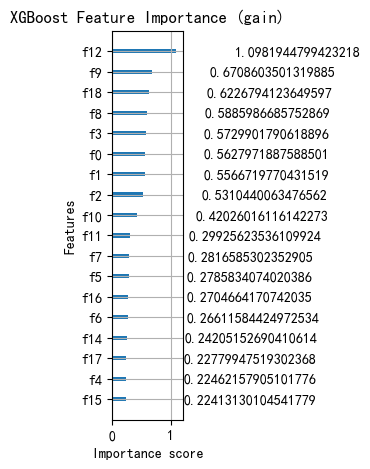

In [175]:
# 绘制特征重要性图
xgb.plot_importance(best_model, max_num_features=18, importance_type='gain') # weight/gain/cover
#分裂 Gain：一次分裂带来的目标函数下降值（误差减少量），总 Gain = 这个特征所有分裂点产生的 Gain 全部累加和
plt.title('XGBoost Feature Importance (gain)')
plt.tight_layout()
plt.show()

In [176]:
# 读取全部特征权重（包含0权重的f17）
score_dict = best_model.get_booster().get_score(importance_type="gain")
#训练送入的 X 矩阵是纯数组 / 无列名 DataFrame，XGBoost 的 sklearn 接口无法捕获字符串格式的特征名，feature_names_in_ 属性不存在，直接改用你手动定义的 fin_all_fac 列表遍历即可，不用读取模型内置名称。
#all_feature = best_model.feature_names_in_


# 循环打印所有特征gain，无贡献自动补0
for i in range(18):
    f_key = f"f{i}"
    gain_val = score_dict.get(f_key, 0.0)
    print(f"{f_key} | gain = {gain_val:.6f}")

f0 | gain = 0.562797
f1 | gain = 0.556672
f2 | gain = 0.531044
f3 | gain = 0.572990
f4 | gain = 0.224622
f5 | gain = 0.278583
f6 | gain = 0.266116
f7 | gain = 0.281659
f8 | gain = 0.588599
f9 | gain = 0.670860
f10 | gain = 0.420260
f11 | gain = 0.299256
f12 | gain = 1.098194
f13 | gain = 0.205188
f14 | gain = 0.242052
f15 | gain = 0.224131
f16 | gain = 0.270466
f17 | gain = 0.227799


In [177]:
print(score_dict)

{'f0': 0.5627971887588501, 'f1': 0.5566719770431519, 'f2': 0.5310440063476562, 'f3': 0.5729901790618896, 'f4': 0.22462157905101776, 'f5': 0.2785834074020386, 'f6': 0.26611584424972534, 'f7': 0.2816585302352905, 'f8': 0.5885986685752869, 'f9': 0.6708603501319885, 'f10': 0.42026016116142273, 'f11': 0.29925623536109924, 'f12': 1.0981944799423218, 'f13': 0.20518754422664642, 'f14': 0.24205152690410614, 'f15': 0.22413130104541779, 'f16': 0.2704664170742035, 'f17': 0.22779947519302368, 'f18': 0.6226794123649597}


In [178]:
x=list(score_dict.items())

In [179]:
x

[('f0', 0.5627971887588501),
 ('f1', 0.5566719770431519),
 ('f2', 0.5310440063476562),
 ('f3', 0.5729901790618896),
 ('f4', 0.22462157905101776),
 ('f5', 0.2785834074020386),
 ('f6', 0.26611584424972534),
 ('f7', 0.2816585302352905),
 ('f8', 0.5885986685752869),
 ('f9', 0.6708603501319885),
 ('f10', 0.42026016116142273),
 ('f11', 0.29925623536109924),
 ('f12', 1.0981944799423218),
 ('f13', 0.20518754422664642),
 ('f14', 0.24205152690410614),
 ('f15', 0.22413130104541779),
 ('f16', 0.2704664170742035),
 ('f17', 0.22779947519302368),
 ('f18', 0.6226794123649597)]

In [183]:
df_gain=pd.DataFrame(x,columns=['fac_name','total_gain'])#单特征在模型所有决策树所有分裂节点上的累计的损失减少总量

In [184]:
df_gain

,fac_name,total_gain
0,f0,0.562797
1,f1,0.556672
2,f2,0.531044
3,f3,0.572990
4,f4,0.224622
5,f5,0.278583
6,f6,0.266116
7,f7,0.281659
8,f8,0.588599
9,f9,0.670860
